# Imports

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import classification_report





# Charger, observer et comprendre le dataset

In [4]:
df = pd.read_csv('credit.csv')

y = df['Loan_Status']
X = df.drop(columns=['Loan_Status','Loan_ID'])
X_columns = X.columns
print(X_columns)

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')


# Transformer les données catégorielles en données numériques

In [5]:
X_columns = X.columns
print(X_columns)
encoder = OrdinalEncoder()
print(X)
X = encoder.fit_transform(X)
print(X)

encoder = LabelEncoder()
y = encoder.fit_transform(y)

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')
     Gender Married Dependents     Education Self_Employed  ApplicantIncome  \
0      Male      No          0      Graduate            No             5849   
1      Male     Yes          1      Graduate            No             4583   
2      Male     Yes          0      Graduate           Yes             3000   
3      Male     Yes          0  Not Graduate            No             2583   
4      Male      No          0      Graduate            No             6000   
..      ...     ...        ...           ...           ...              ...   
609  Female      No          0      Graduate            No             2900   
610    Male     Yes         3+      Graduate            No             4106   
611    Male     Yes          1      Graduate            No             

# Afficher et traiter les données manquantes
Pour traiter les données manquantes, regarder `SimpleImputer` ou `KNNImputer`

In [6]:
imputer = KNNImputer(n_neighbors=5)

X = imputer.fit_transform(X)


# Standardiser les données

In [7]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

print(X)


[[ 0.4814512  -1.3709104  -0.76438894 ...  0.30760399  0.45080053
   1.22329839]
 [ 0.4814512   0.73238542  0.23038598 ...  0.30760399  0.45080053
  -1.31851281]
 [ 0.4814512   0.73238542 -0.76438894 ...  0.30760399  0.45080053
   1.22329839]
 ...
 [ 0.4814512   0.73238542  0.23038598 ...  0.30760399  0.45080053
   1.22329839]
 [ 0.4814512   0.73238542  1.22516091 ...  0.30760399  0.45080053
   1.22329839]
 [-2.11162808 -1.3709104  -0.76438894 ...  0.30760399 -2.39100157
  -0.04760721]]


# Séparer le dataset en train et test

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Régression logistique
Entrainer une régression logistique avec les hyper-paramètres par défaut

In [9]:
regr_log = LogisticRegression()

regr_log.fit(X_train, y_train)

LogisticRegression()

In [10]:
print(f'Train acc: {regr_log.score(X_train, y_train)}')
print(f'Test acc: {regr_log.score(X_test, y_test)}')

Train acc: 0.8126272912423625
Test acc: 0.8048780487804879


# KNN
Entrainer un KNN avec les hyper-paramètres par défaut
Avec `GridSearchCV` ou `RandomizedSearchCV`, optimiser les hyper-paramètres. Utiliser une validation croisée de 5 splits. Vous explorerez les paramètres suivants:
- k : 3, 5, 7, 9, 11,
- poids : uniform, distance,
- distances : euclidean, manhattan, minkowski

In [11]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred_train = knn.predict(X_train)
y_pred_test = knn.predict(X_test)

print(f'Train acc : {accuracy_score(y_train, y_pred_train)}')
print(f'Test acc : {accuracy_score(y_test, y_pred_test)}')

Train acc : 0.8044806517311609
Test acc : 0.7479674796747967


In [12]:
param_grid_knn = {
    'n_neighbors': [3,5,7,9,11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

In [13]:
grid_search = GridSearchCV(estimator=knn, scoring='accuracy', param_grid=param_grid_knn, cv=5, n_jobs=-1) #cv pour cross validation, verbose pour montrer les étapes qui sont effectuées

In [14]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': [3, 5, 7, 9, 11],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [15]:
grid_search.best_params_

{'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}

In [16]:
knn_best = grid_search.best_estimator_

y_pred_train = knn_best.predict(X_train)
y_pred_test = knn_best.predict(X_test)

print(f'Train acc : {accuracy_score(y_train, y_pred_train)}')
print(f'Test acc : {accuracy_score(y_test, y_pred_test)}')

Train acc : 0.8085539714867617
Test acc : 0.8130081300813008


# SVM
Entrainer un SVM avec les hyper-paramètres par défaut
Avec `GridSearchCV` ou `RandomizedSearchCV`, optimiser les hyper-paramètres. Utiliser une validation croisée de 5 splits. Vous explorerez les paramètres suivants:
- C : 0.01, 0.1, 1, 10, 100,
- noyau : linear, poly, rbf, sigmoid,
- gamma : scale, auto, 0.001, 0.01, 0.1, 1,
- degrée du polynome : 2, 3, 4, 5

In [17]:
clf = SVC()

clf.fit(X_train, y_train)

print(f'Train acc: {clf.score(X_train, y_train)}')
print(f'Test acc: {clf.score(X_test, y_test)}')



Train acc: 0.8167006109979633
Test acc: 0.8048780487804879


In [18]:
param_grid_svm = {
    'C': [00.1, 0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'degree': [2,3,4,5]
}

In [19]:
grid_search = GridSearchCV(estimator=clf, scoring='accuracy', param_grid=param_grid_svm, cv=5, n_jobs=-1) #cv pour cross validation, verbose pour montrer les étapes qui sont effectuées

In [20]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 0.1, 1, 10, 100], 'degree': [2, 3, 4, 5],
                         'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
                         'kernel': ['linear', 'rbf', 'poly', 'sigmoid']},
             scoring='accuracy')

In [21]:
grid_search.best_estimator_

SVC(C=0.1, degree=2, kernel='linear')

In [22]:
clf_best = grid_search.best_estimator_

y_pred_train = clf_best.predict(X_train)
y_pred_test = clf_best.predict(X_test)

print(f'Train acc : {accuracy_score(y_train, y_pred_train)}')
print(f'Test acc : {accuracy_score(y_test, y_pred_test)}')

Train acc : 0.8085539714867617
Test acc : 0.8048780487804879


# DecisionTree
Entrainer un arbre de décision avec les hyper-paramètres par défaut
Avec `GridSearchCV` ou `RandomizedSearchCV`, optimiser les hyper-paramètres. Utiliser une validation croisée de 5 splits. Vous explorerez les hyper-paramètres suivants:
- critère : gini, entropy,
- profondeur maximale : None, 10, 20, 30, 40, 50,
- nombre minimum d'exemples par split : 2, 5, 10, 20,
- nombre minimum d'exemples par feuille : 1, 2, 4, 6,
- nombre de features maximum : None, sqrt, log2

In [23]:
decision_tree = DecisionTreeClassifier()

decision_tree.fit(X_train, y_train)

print(f'Train acc: {decision_tree.score(X_train, y_train)}')
print(f'Test acc: {decision_tree.score(X_test, y_test)}')

Train acc: 1.0
Test acc: 0.7398373983739838


In [24]:
param_grid_decision_tree = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2,5,10,20],
    'min_samples_leaf': [1,2,4,6],
    'max_features': [None, 'sqrt', 'log2']
}

In [25]:
grid_search = GridSearchCV(estimator=decision_tree, scoring='accuracy', param_grid=param_grid_decision_tree, cv=5, n_jobs=-1) #cv pour cross validation, verbose pour montrer les étapes qui sont effectuées

In [26]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20, 30, 40, 50],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4, 6],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='accuracy')

In [27]:
grid_search.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=40, max_features='log2',
                       min_samples_leaf=6, min_samples_split=20)

In [28]:
decision_tree_best = grid_search.best_estimator_

y_pred_train = decision_tree_best.predict(X_train)
y_pred_test = decision_tree_best.predict(X_test)

print(f'Train acc : {accuracy_score(y_train, y_pred_train)}')
print(f'Test acc : {accuracy_score(y_test, y_pred_test)}')

Train acc : 0.8044806517311609
Test acc : 0.6747967479674797


# RandomForest
Entrainer une forêt aléatoire avec les paramètres par défaut
Avec `GridSearchCV` ou `RandomizedSearchCV`, optimiser les hyper-paramètres. Utiliser une validation croisée de 5 splits. Vous explorerez les hyper-paramètres suivants:
- nombre d'arbres : 50, 100, 200, 300,
- critère : gini, entropy,
- profondeur maximale : None, 10, 20, 30, 40, 50,
- nombre minimum d'exemples par split : 2, 5, 10, 20,
- nombre minimum d'exemples par feuille : 1, 2, 4, 6,
- nombre de features maximum : None, sqrt, log2,
- remise des exemples : vrai, faux

In [29]:
random_forest = RandomForestClassifier()

random_forest.fit(X_train, y_train)

print(f'Train acc: {random_forest.score(X_train, y_train)}')
print(f'Test acc: {random_forest.score(X_test, y_test)}')

Train acc: 1.0
Test acc: 0.7967479674796748


In [30]:
param_grid_random_forest = {
    'n_estimators': [20,100,200,300],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2,5,10,20],
    'min_samples_leaf': [1,2,4,6],
    'max_features': [None, 'sqrt', 'log2'],
    'bootstrap': [True, False]
}

In [31]:
randomized_search = RandomizedSearchCV(estimator=random_forest, scoring='accuracy', param_distributions=param_grid_random_forest, cv=5, n_jobs=-1, n_iter=1000) # relancer avec + de n_iter

In [32]:
randomized_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=1000,
                   n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [None, 10, 20, 30, 40, 50],
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4, 6],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'n_estimators': [20, 100, 200, 300]},
                   scoring='accuracy')

In [33]:
randomized_search.best_estimator_

RandomForestClassifier(criterion='entropy', max_depth=30, min_samples_leaf=4,
                       min_samples_split=10, n_estimators=200)

In [34]:
random_forest_best = randomized_search.best_estimator_

y_pred_train = random_forest_best.predict(X_train)
y_pred_test = random_forest_best.predict(X_test)

print(f'Train acc : {accuracy_score(y_train, y_pred_train)}')
print(f'Test acc : {accuracy_score(y_test, y_pred_test)}')

Train acc : 0.8329938900203666
Test acc : 0.8048780487804879


# Rapporter et analyser les résultats obtenir. Choisir le meilleur modèle

| algo | hyperparams | train | test |
|:----:|:-----------:|:-----:|:----:|
|Regression logistique|default|0.80|0.82|
|KNN|default|0.81|0.80|
|KNN|metric: euclidean, n_neighbors: 11, weights: uniform|0.81|0.82|
|SVM|default|0.80|0.82|
|SVM|C: 1, gamma: scale, kernel: rbf|0.82|0.82|
|Decision Tree|default|1.00|0.65|
|Decision Tree|max_features='sqrt', min_samples_leaf=4, min_samples_split=20|0.82|0.72|
|Random Forest|default|1.00|0.78|
|Random Forest|max_depth=50, min_samples_leaf=2, min_samples_split=20, n_estimators=20|0.84|0.78|

## Meilleur modèle
Le meilleur modèle est l'algorithme SVM avec les hyper-paramètres suivant:
* C: 1
* gamma: scale
* kernel: rbf




# Analyser le meilleur modèle
En utilisant `classification_report`, afficher différentes métriques en train et en test du modèle choisit. Afficher la matrice de confusion en train et en test de ce même modèle. Qu'en concluez-vous sur la qualité de ce modèle?

In [35]:
clf = SVC(C=1, gamma='scale', kernel='rbf')
clf.fit(X_train, y_train)
y_pred_train = clf_best.predict(X_train)
y_pred_test = clf_best.predict(X_test)

y_true = y_train
y_pred = y_pred_train
target_names = ['Y', 'N']

print(classification_report(y_true, y_pred, target_names=target_names))


              precision    recall  f1-score   support

           Y       0.93      0.42      0.58       154
           N       0.79      0.99      0.88       337

    accuracy                           0.81       491
   macro avg       0.86      0.70      0.73       491
weighted avg       0.83      0.81      0.78       491



# Exercice 1 - Feature Selection

In [ ]:
import seaborn as sns

In [62]:
credit_df = pd.DataFrame(data=X_train, columns=X_columns)

<Axes: >

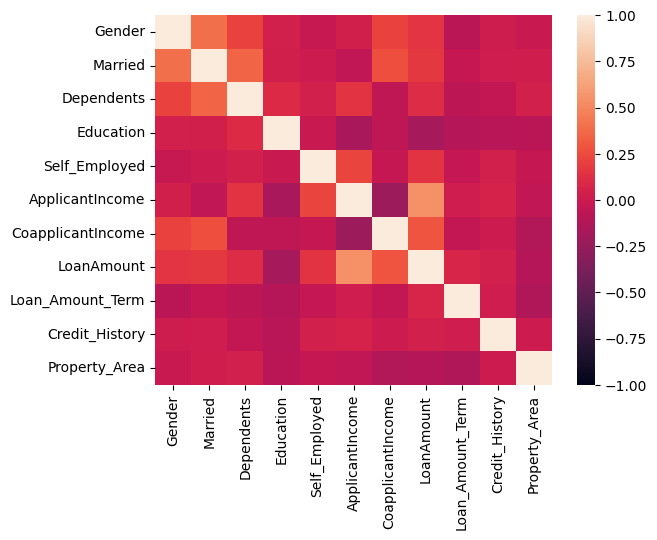

In [64]:
matrix = credit_df.corr()

sns.heatmap(matrix, annot=False, vmin=-1, vmax=1)

Remarques : très peu de corrélation en règle générale, légère corrélation entre ApplicantIncome et LoanAmmount

In [67]:
from boruta import BorutaPy

y_pred_train = random_forest_best.predict(X_train)
y_pred_test = random_forest_best.predict(X_test)

In [69]:
feat_selector = BorutaPy(random_forest_best)

feat_selector.fit(X, y)

BorutaPy(estimator=RandomForestClassifier(criterion='entropy', max_depth=30,
                                          min_samples_leaf=4,
                                          min_samples_split=10,
                                          n_estimators=1000,
                                          random_state=RandomState(MT19937) at 0x267A6586D40),
         random_state=RandomState(MT19937) at 0x267A6586D40)

In [79]:
X_columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')

In [ ]:
feat_selector.support_

array([False, False, False, False, False, False, False,  True, False,
        True, False])

In [80]:
feat_selector_columns = feat_selector.support_
interesting_columns = []
for i in range(len(feat_selector_columns)):
    if feat_selector_columns[i] == True:
        interesting_columns.append(X_columns[i])

print(interesting_columns)

['LoanAmount', 'Credit_History']


In [71]:
feat_selector.ranking_

array([10,  6,  5,  8,  9,  2,  3,  1,  7,  1,  4])

In [72]:
X_filtered = feat_selector.transform(X)

In [74]:
X_filtered

array([[ 0.18492069,  0.45080053],
       [-0.12558823,  0.45080053],
       [-1.32826365,  0.45080053],
       ...,
       [ 1.64562466,  0.45080053],
       [ 0.98961988,  0.45080053],
       [-0.0162541 , -2.39100157]])